# Mini-project 5.3 Detecting the anomalous activity of a ship’s engine

**Welcome to your first mini-project: Detecting the anomalous activity of a ship’s engine!**

This mini-project allows you to dive deep into a real-world challenge, applying and honing the data science skills you've been cultivating so far. In this immersive exploration into detecting the anomalous activity of a ship’s engine, you can practically apply the concepts you've learned over the past few weeks.

A poorly maintained ship engine in the supply chain industry can lead to inefficiencies, increased fuel consumption, higher risks of malfunctions, and potential safety hazards. Your challenge in this project is to apply critical thinking and ML concepts to design and implement a robust anomaly detection model.

Please set aside approximately **12 hours** to complete the mini-project.

<br></br>

## **Business context**
You are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). As you work through this project, keep in mind that, typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

Your task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Therefore, you’ll explore the data and:
- employ preprocessing and feature engineering
- perform anomaly detection.

You must prepare a report illustrating your insights to the prospective stakeholders, explaining your approach in identifying anomalies, presenting your findings and including recommendations.

<br></br>

> **Disclaimer**
>
> Please note that although a real-life data set was provided, the business context in this project is fictitious. Any resemblance to companies and persons (living or dead) is coincidental. The course designers and hosts assume no responsibility or liability for any errors or omissions in the content of the business context and data sets. The information in the data sets is provided on an 'as is' basis with no guarantees of completeness, accuracy, usefulness, or timeliness.

<br></br>

## **Objective**
By the end of this mini-project, you will be able to understand and apply statistical and ML methods for detecting anomalies.

In the Notebook, you will:
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.

You will also write a report summarising the results of your findings and recommendations.

<br></br>

## **Assessment criteria**
By completing this project, you will be able to provide evidence that you can:
- demonstrate enhanced problem-solving skills and proposed strategic solutions by systematically analysing complex organisational challenges
- identify meaningful patterns in complex data to evidence advanced critical and statistical thinking skills
- select statistical techniques appropriate to a solutions design approach and evidence the ability to evaluate their effectiveness
- demonstrate enhanced data representation and improved model performance by systematically implementing relevant techniques
- design innovative solutions through critically selecting, evaluating and implementing effective unsupervised learning techniques.

<br></br>
> **Declaration**
>
> By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the Cambridge plagiarism regulations.

In [ ]:
# URL to import data set from GitHub.
# url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'


# Importing necessary libraries


In [ ]:
# Import the necessary libararies.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


# Import and view DataFrame

In [ ]:
# Import the Dataframe

url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

df = pd.read_csv(url)

# Make a copy of the data set.
df1 = df.copy()

In [ ]:
# View the shape and first few rows of the dataset.
print(df.shape)
df.head()

(19535, 6)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


**Observations:** *Engine data is composed of 19535 observations with 6 features.*

## EDA (Exploratory Data Analysis).


In [ ]:
# Determine the metadata of the DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


In [ ]:
# Check for missing value
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0


In [ ]:
# Check for duplicate values
duplicated_rows = df[df.duplicated()]
print('Number of duplicated rows:', duplicated_rows.shape[0])

Number of duplicated rows: 0


**Observations:** *The DataFrame show that there is no missing value and no duplicate rows.*

## Descriptive Statistics of the Egine data

In [ ]:
# Descriptive Stats:

df.describe().round(2)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.00,19535.00,19535.00,19535.00,19535.00,19535.00
mean,791.24,3.30,6.66,2.34,77.64,78.43
std,267.61,1.02,2.76,1.04,3.11,6.21
min,61.00,0.00,0.00,0.00,71.32,61.67
25%,593.00,2.52,4.92,1.60,75.73,73.90
50%,746.00,3.16,6.20,2.17,76.82,78.35
75%,934.00,4.06,7.74,2.85,78.07,82.92
max,2239.00,7.27,21.14,7.48,89.58,195.53


**Observations:**
- **- Engine rpm:** *"High spread (std = 267.61). Mean is slightly pulled up, indicating a slight positive skew or high outliers."*
- **- Lub oil pressure:** *"Mean and median are close, suggesting symmetry. The minimum of 0.0 requires investigation as a pressure reading of zero may indicate a fault or shutdown."*
- **- Fuel pressure:** *Significant difference between mean and median suggests a positive skew due to the high maximum (21.14) and potential outliers. The minimum of 0.0 also needs review.*
- **- Coolant pressure:** *"Similar to fuel pressure, a slight positive skew is present. Lowest mean value in the dataset. Minimum of 0.0 is concerning."*
- **- Lub oil temp:** *"Low standard deviation (3.11) and tight range. Mean and median are very close, indicating a highly stable and symmetrical distribution within an expected operational range."*
- **- Coolant temp:** *"The mean and median are extremely close, but the Maximum value of 195.53 is highly anomalous and likely an error or a severe outlier, as it is far outside a normal coolant temperature range. This feature requires immediate outlier treatment."*

## Data Visualization.
- Visualising DataFrame Distribution on Histogram.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

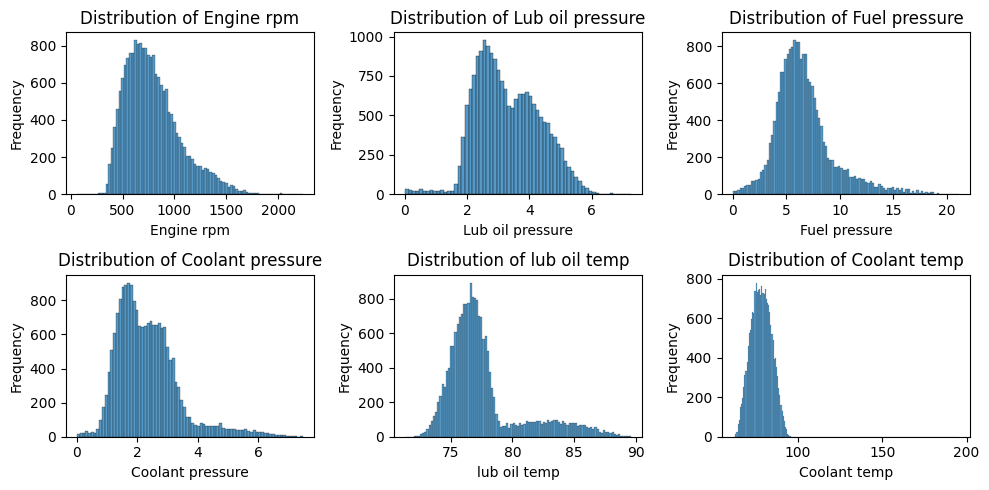

In [ ]:
# Create a hsitogram plot
features = df.columns

plt.figure(figsize=(10,5))
for i, feature in enumerate(features, 1):
  plt.subplot(2, 3, i)
  sns.histplot(df[feature])
  plt.title(f'Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')

plt.tight_layout()
plt

**Observations**
- **Engine RPM:** *Shows a dispersed distribution with a slight positive skew; the tail extending toward higher values confirms the presence of outliers.*
- **Lub Oil Pressure:** *Generally follows a symmetrical, bell-shaped curve, though readings near zero are noted as potential indicators of operational failure.*
- **Fuel Pressure:**  *Exhibiting a strong rightward skew, this feature has a long tail of high-pressure readings; the notable gap between the mean and median suggests significant outliers.*
- **Coolant Pressure:** *Displays a slight positive skew; while data is mostly clustered, instances of high pressure and values near zero require further scrutiny.*
- **Lub Oil Temp:** *Characterized by a highly stable, narrow, and centralized normal distribution, indicating a very consistent operating range with minimal deviation.*
- **Coolant Temp:** *While the core distribution is relatively symmetrical, it is marked by extreme high-end outliers, specifically a critical maximum value of 195.53, which requires immediate investigation.*

- Visualising the DataFrame using Boxplots.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

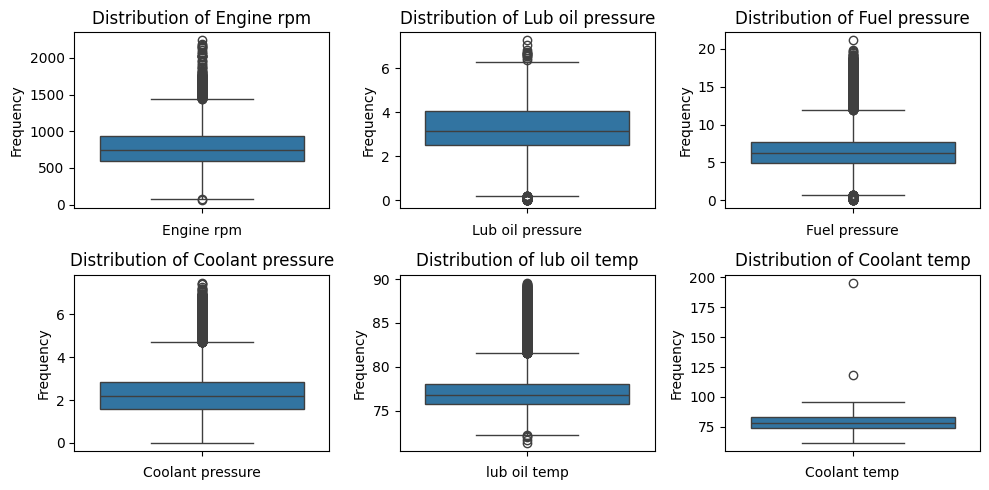

In [ ]:
# View DataFrame from Boxplots.
features = df.columns

plt.figure(figsize=(10,5))
for i, feature in enumerate(features, 1):
  plt.subplot(2, 3, i)
  sns.boxplot(df[feature])
  plt.title(f'Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')

plt.tight_layout()
plt

**Observations:**
- *All features exhibit outliers to varying degrees. Engine rpm, Lub oil pressure, Fuel pressure, and Coolant temp show particularly widespread or extreme outliers, highlighting potential areas of concern that an anomaly detection system would focus on. The Coolant temp in particular has highly anomalous maximum values that clearly indicate critical issues.*

# Statistical method of anomaly Detection:

## IQR Method:

In [ ]:
# Calculate IQR for each feature and store only the anomalous values

for i, feature in enumerate(features, 1):
  q1 = df[feature].quantile(0.25)
  q3 = df[feature].quantile(0.75)
  iqr = q3 - q1
  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr


# create new flagged column for each feature in df.
  df[f'{feature}_outlier'] = ((df[feature] < lower_limit) | (df[feature] > upper_limit)).astype(int)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0


- ## Sum up the outliers in each row and determine the number that make up between 1 -5 %.

In [ ]:
# Generate sum of outliers in each row.
outliers = []
for column in df.columns:
    if column.endswith('_outlier'):
        outliers.append(column)
df['sum_outliers'] = df[outliers].sum(axis=1)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,sum_outliers
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0


In [ ]:
# View the sum of ouliers in each row
df['sum_outliers']

,sum_outliers
0,0
1,1
2,1
3,0
4,0
...,...
19530,0
19531,0
19532,1
19533,0


- ### Determining the number of observations and percentage of the sum of outliers within the 1-5 % limit.

In [ ]:
# Percentage of outliers in at least 1 feature.
length_df = len(df)
outlier_1 = df[df['sum_outliers']>= 1]

length_outliers_1 = len(outlier_1)
percentage_outliers_1 = (length_outliers_1 / length_df) * 100

print('Total number of outlier in at leat one feature:', outlier_1.shape)
print(f'Percentage of outliers: {percentage_outliers_1:.2f}%')

Total number of outlier in at leat one feature: (4636, 13)
Percentage of outliers: 23.73%


In [ ]:
# Percentage of outliers with sum at least 2.

length_outliers_2 = len(df[df['sum_outliers'] >= 2])
percentage_outliers_2 = (length_outliers_2 / length_df) * 100

print(f'Total number of outlier in at least 2 features:', length_outliers_2)
print(f'Percentage of outliers: {percentage_outliers_2:.2f}%')

Total number of outlier in at least 2 features: 422
Percentage of outliers: 2.16%


In [ ]:
# Percentage of outliers with sum least 3.
length_outliers_3 = len(df[df['sum_outliers'] >= 3])
percentage_outliers_3 = (length_outliers_3 / length_df) * 100

print(f'Total number of outlier in at least 3 features:', length_outliers_3)
print(f'Percentage of outliers: {percentage_outliers_3:.2f}%')

Total number of outlier in at least 3 features: 11
Percentage of outliers: 0.06%


In [ ]:
# Percentage of outliers with sum least 4.
length_outliers_4 = len(df[df['sum_outliers'] >= 4])
percentage_outliers_4 = (length_outliers_4 / length_df) * 100

print(f'Total number of outlier in at least 4 features:', length_outliers_4)
print(f'Percentage of outliers: {percentage_outliers_4:.2f}%')

Total number of outlier in at least 4 features: 0
Percentage of outliers: 0.00%


 **Observation:**
 - *Result show that 422 observations hassum of outliers at least 2 and amount to a percentage between 1 - 5%.*
 - *Multivariant approach was adopted selecting the outliers because univariant approach could not deliver the actual anomalies.*

Create and view clean Data set.

In [ ]:
# Creating a claen DataFrame by filtering out rows with atleast 2 flagged outliers.

df_clean = df[df['sum_outliers'] < 2].copy()

df_clean



,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,sum_outliers
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19530,681,3.598792,7.300853,1.083391,76.206955,69.848780,0,0,0,0,0,0,0
19531,580,2.243040,5.242489,1.471350,76.884907,87.098119,0,0,0,0,0,0,0
19532,616,3.310048,3.787693,6.001031,75.889810,72.220009,0,0,0,1,0,0,1
19533,1163,2.731726,3.703595,2.951684,76.784626,81.400088,0,0,0,0,0,0,0



# Machine Learning (ML) Based Anomaly detection.


## One-Class SVM Method:

In [ ]:
# Import the copy of the DataFrame
df1
df2 = df1.copy()
df2

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220
...,...,...,...,...,...,...
19530,681,3.598792,7.300853,1.083391,76.206955,69.848780
19531,580,2.243040,5.242489,1.471350,76.884907,87.098119
19532,616,3.310048,3.787693,6.001031,75.889810,72.220009
19533,1163,2.731726,3.703595,2.951684,76.784626,81.400088


In [ ]:
# Applying feature Scaling using Z-Score Standardisation.
standard_scaler = StandardScaler()
df_scaled = standard_scaler.fit_transform(df1)
df_model = pd.DataFrame(df_scaled, columns=df1.columns)
df_model.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


In [ ]:
# Peform One_Class SVM Model.
svm_model = OneClassSVM(kernel='rbf', gamma=0.2, nu=0.02)
svm_model.fit(df_model)

OneClassSVM(gamma=0.2, nu=0.02)

In [ ]:
# Predict the class (normal or anomaly).
y_pred = svm_model.predict(df_model)
y_pred

array([ 1, -1,  1, ...,  1,  1,  1])

In [ ]:
# Create DataFrame for the predicted model.
df_svm = pd.DataFrame(df_model, columns=df1.columns)
df_svm['anomaly'] = y_pred
df_svm.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412,1
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690,1
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913,1
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491,1


In [ ]:
# View outliers in the DataFrame (labeled as -1).
df_anomalies = df_svm[df_svm['anomaly'] == -1]
print(df_anomalies.shape)
df_anomalies

(389, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
9,0.055159,0.629502,5.245553,-0.736041,-0.874377,-1.017425,-1
17,1.946010,2.603387,0.328859,3.470415,0.030684,1.648979,-1
115,-2.728802,0.619474,0.518973,-0.473084,-0.133790,-0.699133,-1
144,3.627597,-1.572300,-0.843105,0.181408,2.927422,0.638962,-1
...,...,...,...,...,...,...,...
19185,-0.490423,-0.043952,3.832939,0.726240,3.528197,-1.107764,-1
19266,-0.247527,1.004805,-0.121138,0.490678,-2.032029,1.078955,-1
19281,0.443792,2.521266,1.357031,3.813952,-0.606725,-1.559458,-1
19375,0.776373,-3.109890,-0.561144,1.546654,-0.963731,2.243787,-1


In [ ]:
# Calculate the percentage of anomalies.

percentage_anomalies = (len(df_anomalies) / len(df_svm)) * 100

print(f'Total Data points in df_svm:', len(df_svm))
print(f'Total Number of anomalous observations detected:',len(df_anomalies))
print(f'Percentage of anomalies: {percentage_anomalies:.1f}%')

Total Data points in df_svm: 19535
Total Number of anomalous observations detected: 389
Percentage of anomalies: 2.0%


In [ ]:
#Tuning gamma = 0.1 and nu = 0.03
svm_model = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.03)
svm_model.fit(df_model)

y_pred = svm_model.predict(df_model)

df_svm['anomaly'] = y_pred
df_anomalies = df_svm[df_svm['anomaly'] == -1]

percentage_adj_1 = (len(df_anomalies) / len(df_svm)) * 100


print(f'Total Number of anomalous observations:',len(df_anomalies))
print(f'Percentage of anomalies: {percentage_adj_1:.1f}%')

Total Number of anomalous observations: 586
Percentage of anomalies: 3.0%


In [ ]:
# Tuning gamma = 0.2, and nu = 0.04
svm_model = OneClassSVM(kernel='rbf', gamma=0.2, nu=0.04)
svm_model.fit(df_model)

y_pred = svm_model.predict(df_model)
df_svm['anomaly'] = y_pred
df_anomalies = df_svm[df_svm['anomaly'] == -1]
percentage_adj_2 = (len(df_anomalies) / len(df_svm)) * 100


print(f'Total Number of anomalous observations:',len(df_anomalies))
print(f'Percentage of anomalies: {percentage_adj_2:.1f}%')

Total Number of anomalous observations: 790
Percentage of anomalies: 4.0%


In [ ]:
# Tuning gamma = 0.1, and nu = 0.05
svm_model = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
svm_model.fit(df_model)

y_pred = svm_model.predict(df_model)
df_svm['anomaly'] = y_pred
df_anomalies = df_svm[df_svm['anomaly'] == -1]
percentage_adj_2 = (len(df_anomalies) / len(df_svm)) * 100


print(f'Total Number of anomalous observations:',len(df_anomalies))
print(f'Percentage of anomalies: {percentage_adj_2:.1f}%')

Total Number of anomalous observations: 978
Percentage of anomalies: 5.0%


**Observations**:
- *One-Class SVM model show that, a total 978 observations are outliers accounting for the given 1.0 -5.0 % of the total data set.*
- *Tuning nu to match the expected anomaly percentage (e.g., within 1-5%) appears to be an efficient strategy for this dataset than tuning gamma.*
- *A smaller nu leads to a tighter boundary, potentially identifying more points as anomalies, while a larger nu results in a looser boundary.*

- ## Visualising the Output with PCA.

In [ ]:
# Creating a 2D PCA.
pca = PCA(n_components=2)
pca_model = pca.fit_transform(df_model)
pca_df = pd.DataFrame(pca_model, columns=['PC1', 'PC2'])

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum()}")
pca_df.head()

Explained variance ratio: [0.1899485  0.17692968]
Total explained variance: 0.36687817845906473


,PC1,PC2
0,-0.557362,-0.906512
1,-2.177170,-1.201538
2,2.051806,1.039581
3,0.744375,-0.501140
4,-1.629821,-0.473906


In [ ]:
# View the shape of Normalised Data and PCA data.

print("Normalised Data: ", df_scaled.shape)
print("PCA Data for visualisation: ", pca_df.shape)

Normalised Data:  (19535, 6)
PCA Data for visualisation:  (19535, 2)


- ##### The normalised data maintained the same number of rows, but the column has been reduced from 6 to 2 with PCA.

In [ ]:
# Create a 2D PCA merged with the predicted anomalies.
pca_df['anomaly'] = y_pred
pca_df.head()

,PC1,PC2,anomaly
0,-0.557362,-0.906512,1
1,-2.177170,-1.201538,-1
2,2.051806,1.039581,1
3,0.744375,-0.501140,1
4,-1.629821,-0.473906,1


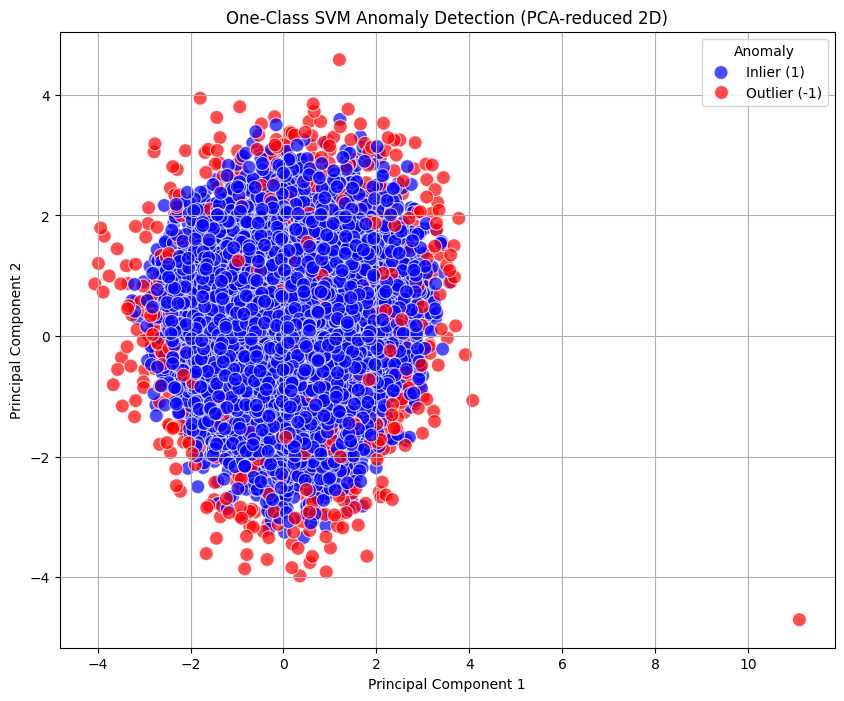

In [ ]:
# Visualize the output in 2D after PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='anomaly', data=pca_df,
    palette={1: 'blue', -1: 'red'},
    markers={1: 'o', -1: 'X'},
    s=100,
    alpha=0.7
)
plt.title('One-Class SVM Anomaly Detection (PCA-reduced 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Anomaly', labels=['Inlier (1)', 'Outlier (-1)'])
plt.grid(True)
plt.show()

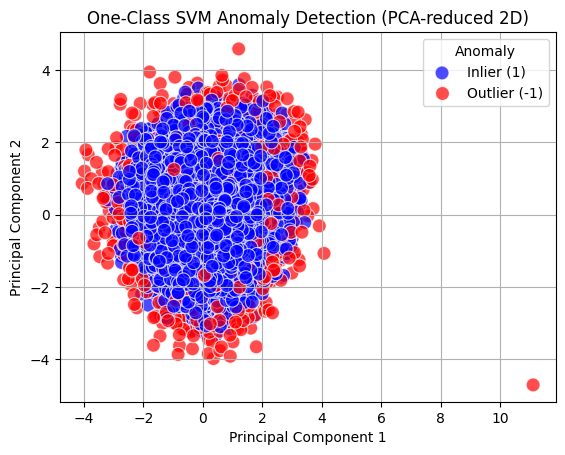

In [ ]:
#Create a plot to visualise PCA  using anomaly as legend.
def plot_embedding(X, title, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    plt.figure(figsize=(12, 8))
    plt.title(title)
    for i in range(X.shape[0]):
        plt.text(X[i, 0], X[i, 1], str(y[i]),
                 color=plt.cm
                 .spectral(y_pred[i] / 10.),
                 fontdict={'weight': 'bold', 'size': 9})
    plt.xticks([])
    plt.yticks([])
    plt.axis('tight')
    plt.show()
    return plt


sns.scatterplot(
    x='PC1', y='PC2', hue='anomaly', data=pca_df,
    palette={1: 'blue', -1: 'red'},
    markers={1: 'o', -1: 'X'},
    s=100,
    alpha=0.7
)
plt.title('One-Class SVM Anomaly Detection (PCA-reduced 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Anomaly', labels=['Inlier (1)', 'Outlier (-1)'])
plt.grid(True)


**Observations:**
- * One_Class SVM,  predicted 978 observations as outliers amounting to 1-5% of the total data set.*
- *Tuning nu to match the expected anomaly percentage (e.g., within 1-5%) appears to be an efficient strategy for this dataset than tuning gamma.*
- *A smaller nu leads to a tighter boundary, potentially identifying more points as anomalies, while a larger nu results in a looser boundary.*

- *On PCA plot, Outliers identified in One-Class SVM tends to be located at the periphery of the main cluster.*

 - *From observation PCA, is not ideal visualization tool in Isolation Forest since it could not distinctly seperate  clusters of the outliers from the main.*

## Isolation Forest Method:

In [ ]:
df2

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220
...,...,...,...,...,...,...
19530,681,3.598792,7.300853,1.083391,76.206955,69.848780
19531,580,2.243040,5.242489,1.471350,76.884907,87.098119
19532,616,3.310048,3.787693,6.001031,75.889810,72.220009
19533,1163,2.731726,3.703595,2.951684,76.784626,81.400088


In [ ]:
# Perform Isolation Forest model (n_estimators = 100, contamiantion = 0.01)..
isolation_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
isolation_forest.fit(df2)

IsolationForest(contamination=0.01, random_state=42)

In [ ]:
# Predict the anomalous observations.
y_pred = isolation_forest.predict(df2)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
# Create a dataframe for the prediction
df_if = pd.DataFrame(df2, columns=df2.columns)
df_if['anomaly'] = y_pred
df_if.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1


In [ ]:
# Isolate the anomalous Data set.
df2_anomaly = df_if[df_if['anomaly'] == -1]
print(df2_anomaly.shape)
df2_anomaly

(196, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
17,1312,5.963439,7.563578,5.931953,77.738876,88.661972,-1
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,-1
157,534,5.922045,18.044686,5.946436,77.292791,74.734372,-1
249,1004,2.745963,16.554492,5.738463,74.621543,83.155235,-1
298,1299,5.660669,14.704443,1.594831,75.551802,68.644834,-1
...,...,...,...,...,...,...,...
18889,1339,0.581040,4.306783,1.280968,86.735736,79.898902,-1
19185,660,3.258873,17.238167,3.088011,88.619302,71.551997,-1
19281,910,5.879543,10.402309,6.287980,75.755957,68.748518,-1
19343,1475,2.184002,6.558549,1.265442,84.933480,88.088609,-1


In [ ]:
# Calculate the percentage of the anomaly.
percentage_anomaly = (len(df2_anomaly) / len(df_if)) * 100

print(f'Total Number of anomalous observations:',len(df2_anomaly))
print(f'Percentage of anomalies: {percentage_anomaly:.2f}%')

Total Number of anomalous observations: 196
Percentage of anomalies: 1.00%


In [ ]:
# Tune the hyperparameters of the Isolation Forest model (n_estimators = 50, contamiantion = 0.03).
isolation_forest = IsolationForest(n_estimators=50, contamination=0.03, random_state=42)
isolation_forest.fit(df2)

y_pred = isolation_forest.predict(df2)
df_if['anomaly'] = y_pred
df2_anomaly = df_if[df_if['anomaly'] == -1]
percentage_anomaly_1 = (len(df2_anomaly) / len(df_if)) * 100


print(f'Total Number of anomalous observations:',len(df2_anomaly))
print(f'Percentage of anomalies: {percentage_anomaly_1:.2f}%')

Total Number of anomalous observations: 587
Percentage of anomalies: 3.00%


In [ ]:
# Fine tune the hyper parameters (n_estimators = 100, contamiantion = 0.05) to improve model prediction.
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
isolation_forest.fit(df2)

y_pred = isolation_forest.predict(df2)
df_if['anomaly'] = y_pred
df2_anomaly = df_if[df_if['anomaly'] == -1]
percentage_anomaly_2 = (len(df2_anomaly) / len(df_if)) * 100


print(f'Total Number of anomalous observations:',len(df2_anomaly))
print(f'Percentage of anomalies: {percentage_anomaly_2:.2f}%')

Total Number of anomalous observations: 977
Percentage of anomalies: 5.00%


In [ ]:
# Fine tune the hyper parameters (n_estimators = 30, contamiantion = 0.06).
isolation_forest = IsolationForest(n_estimators=30, contamination=0.06, random_state=42)
isolation_forest.fit(df2)

y_pred = isolation_forest.predict(df2)
df_if['anomaly'] = y_pred
df2_anomaly = df_if[df_if['anomaly'] == -1]
percentage_anomaly_3 = (len(df2_anomaly) / len(df_if)) * 100


print(f'Total Number of anomalous observations:',len(df2_anomaly))
print(f'Percentage of anomalies: {percentage_anomaly_3:.2f}%')

Total Number of anomalous observations: 1173
Percentage of anomalies: 6.00%


- ##  Visualise the model using PCA

In [ ]:
# Call Normalised Data for PCA visalization.
df_model

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491
...,...,...,...,...,...,...
19530,-0.411949,0.288774,0.233701,-1.208058,-0.461752,-1.382184
19531,-0.789372,-1.038290,-0.511826,-0.833709,-0.243824,1.397013
19532,-0.654845,0.006141,-1.038745,3.537070,-0.563698,-1.000134
19533,1.389218,-0.559945,-1.069205,0.594695,-0.276059,0.478951


In [ ]:
# perform PCA on the normalised data set.
pca_Is = PCA(n_components=2)
pca_model_Is = pca.fit_transform(df_model)
pca_df_Is = pd.DataFrame(pca_model_Is, columns=['PC1', 'PC2'])

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum()}")
pca_df_Is.head()

Explained variance ratio: [0.1899485  0.17692968]
Total explained variance: 0.36687817845906473


,PC1,PC2
0,-0.557362,-0.906512
1,-2.177170,-1.201538
2,2.051806,1.039581
3,0.744375,-0.501140
4,-1.629821,-0.473906


In [ ]:
# Integrate the predicted anomaly into the PCA.
pca_df_Is['anomaly'] = y_pred
pca_df_Is.head()

,PC1,PC2,anomaly
0,-0.557362,-0.906512,1
1,-2.177170,-1.201538,-1
2,2.051806,1.039581,1
3,0.744375,-0.501140,1
4,-1.629821,-0.473906,1


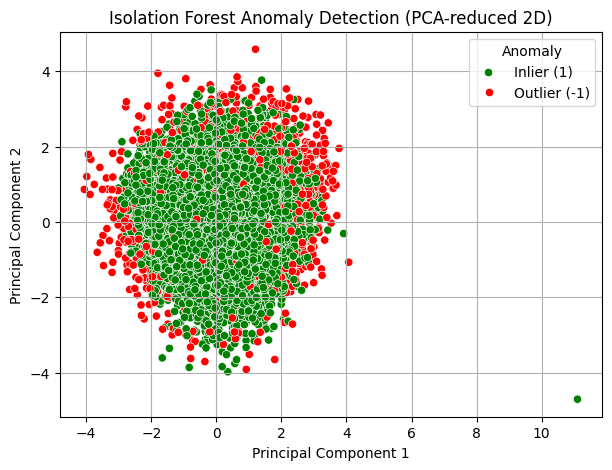

In [ ]:
# Visualise the output on a 2D PCA.
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='PC1', y='PC2', hue='anomaly', data=pca_df_Is,
    palette={1: 'green', -1: 'red'},
    markers={1: 'o', -1: 'X'},
)
plt.title('Isolation Forest Anomaly Detection (PCA-reduced 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Anomaly', labels=['Inlier (1)', 'Outlier (-1)'])
plt.grid(True)
plt.show()

**Observations:**
- *The contamination parameter in Isolation Forest directly controls the expected proportion of outliers in the dataset.*

- *Similar to One_Class SVM, Isolation Forest algorithm predicted 977 observations as outliers amounting to 1 -5% of the total.*

- *Isolation Forest seems to provide a more direct control over the percentage of anomalies through its contamination parameter, often matching the exact percentage specified.*

- *PCA 2D plot shows that outliers identified in Isolation Forest tends to be located at the periphery of the main cluster.*

 - *From observation, PCA is not ideal visualization tool in Isolation Forest since it could not distinctly seperate  clusters of the outliers from the main.*


### Reference:
Devabrat, M. (2022) *Predictive Maintenance on Ship's Main Engine using AI.* [Online] Available at: https://dx.doi.org/10.21227/g3za-v415 [Accessed 9 December 2026].